<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/good_Evaluacion_2_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 2: Preparación de Datos y Modelos de Regresión

**Autores:** Rodrigo Casanova, José Vásquez, Samuel Acuña  
**Correos:** rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl  
**Fecha de creación:** Mayo 2026  
**Versión:** 1.0

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.model_selection import train_test_split

## Contexto y objetivo del proyecto

Una empresa de construcción que opera en ciudades como Concepción, Valdivia, Temuco y Punta Arenas busca optimizar la planificación de sus obras considerando las condiciones climáticas.

A partir del análisis de variables como precipitaciones, horas de sol y temperatura, la empresa ajusta sus cronogramas de trabajo para reducir retrasos y mejorar la eficiencia operativa.

## Carga del conjunto de datos


In [3]:
!wget https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv

data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory = False)
data.head()

--2026-05-18 22:56:11--  https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.08s   

2026-05-18 22:56:11 (51.2 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


### Interpretación:

Se cargó el conjunto de datos climáticos correspondiente al año 2025. El dataset contiene observaciones meteorológicas asociadas a distintas localidades de Chile, incluyendo variables como temperatura, humedad, precipitación, nubosidad, viento y duración de sol.

## Exploración inicial del conjunto de datos

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [5]:
data.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,latitud,longitud,is_rainy_hour
count,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000
mean,10.644075,79.042842,8.337603,0.138981,62.114977,11.930189,205.227225,0.136601,0.495882,1221.216663,-42.134914,-72.448638,0.184714
std,5.213359,16.228987,6.350746,0.582210,41.871036,8.474665,101.410042,0.577866,0.499991,1650.360797,6.456137,0.920869,0.388071
min,-5.100000,15.230701,-8.741941,0.000000,0.000000,0.000000,0.367278,0.000000,0.000000,0.000000,-53.162569,-73.245986,0.000000
25%,7.050000,68.349886,3.876656,0.000000,13.000000,5.649248,139.531913,0.000000,0.000000,0.000000,-43.151237,-73.099151,0.000000
50%,10.400000,82.217838,8.232820,0.000000,88.000000,9.940824,229.398790,0.000000,0.000000,0.000000,-39.275008,-72.820372,0.000000
75%,13.700000,92.891105,12.350445,0.000000,100.000000,15.882896,284.036250,0.000000,1.000000,3600.000000,-38.258686,-72.169859,0.000000
max,31.750000,100.000000,32.108310,13.200000,100.000000,65.250920,360.000000,13.200000,1.000000,3600.000000,-36.827070,-70.907822,1.000000


In [6]:
data.shape

(33024, 15)

### Interpretación:

El conjunto de datos contiene 33.024 registros y 15 variables. Se observan variables numéricas asociadas a mediciones climáticas, como temperatura, humedad, precipitación, nubosidad, velocidad del viento y duración de sol. También se identifican variables de ubicación, como localidad, latitud y longitud.

La revisión inicial permite conocer la estructura del dataset, los tipos de datos y la cantidad de registros disponibles antes de iniciar la preparación de datos.

## Identificación de valores duplicados

In [7]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

### Interpretación:

Se revisó la existencia de registros duplicados dentro del conjunto de datos. El resultado indica que no existen filas repetidas, por lo que no fue necesario eliminar registros por duplicidad.

Este hallazgo es importante, ya que permite asegurar que el modelo no será entrenado con observaciones repetidas que puedan sesgar el aprendizaje.

## Identificación de valores nulos

In [8]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


### Interpretación:

Se revisó la existencia de valores nulos en todas las columnas del conjunto de datos. Los resultados muestran que no existen valores faltantes en el dataset original.

A pesar de esto, se mantendrá un tratamiento de nulos dentro del pipeline mediante imputación, ya que esto permite que el modelo sea más robusto en caso de recibir nuevos datos con valores faltantes.

## Identificación de inconsistencias

In [9]:
for columna in [
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "rain",
    "is_day",
    "sunshine_duration",
    "is_rainy_hour"
]:
    print(f"{columna:<25} tiene {len(data[data[columna] < 0])} valores negativos")

relative_humidity_2m      tiene 0 valores negativos
precipitation             tiene 0 valores negativos
cloud_cover               tiene 0 valores negativos
wind_speed_10m            tiene 0 valores negativos
wind_direction_10m        tiene 0 valores negativos
rain                      tiene 0 valores negativos
is_day                    tiene 0 valores negativos
sunshine_duration         tiene 0 valores negativos
is_rainy_hour             tiene 0 valores negativos


In [10]:
print("Humedad fuera de rango:",
      len(data[(data["relative_humidity_2m"] < 0) | (data["relative_humidity_2m"] > 100)]))

print("Dirección del viento fuera de rango:",
      len(data[(data["wind_direction_10m"] < 0) | (data["wind_direction_10m"] > 360)]))

print("Nubosidad fuera de rango:",
      len(data[(data["cloud_cover"] < 0) | (data["cloud_cover"] > 100)]))

Humedad fuera de rango: 0
Dirección del viento fuera de rango: 0
Nubosidad fuera de rango: 0


### Interpretación:

Se revisaron posibles inconsistencias en variables climáticas que, por su naturaleza, no deberían presentar valores negativos o fuera de ciertos rangos.

No se identificaron valores negativos en las variables revisadas. Tampoco se detectaron valores fuera de rango en humedad relativa, dirección del viento ni nubosidad. Por lo tanto, no fue necesario eliminar registros por inconsistencias.

## Identificación de valores atípicos

In [11]:
def buscar_atipicos(data: pd.DataFrame, columna: str) -> pd.DataFrame:
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return data[
        (data[columna] < limite_inferior) |
        (data[columna] > limite_superior)
    ]


def obtener_cantidad_atipicos(data: pd.DataFrame, columnas: list) -> dict:
    total_atipicos = {}

    for columna in columnas:
        atipicos = buscar_atipicos(data, columna)
        total_atipicos[columna] = atipicos.shape[0]

    return total_atipicos

columnas_atipicos = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "rain",
    "sunshine_duration"
]

atipicos_por_columna = obtener_cantidad_atipicos(data, columnas_atipicos)

pd.DataFrame.from_dict(
    atipicos_por_columna,
    orient="index",
    columns=["Cantidad Atípicos"]
)

,Cantidad Atípicos
temperature_2m,476
relative_humidity_2m,130
precipitation,6152
cloud_cover,0
wind_speed_10m,1241
wind_direction_10m,0
rain,6100
sunshine_duration,0


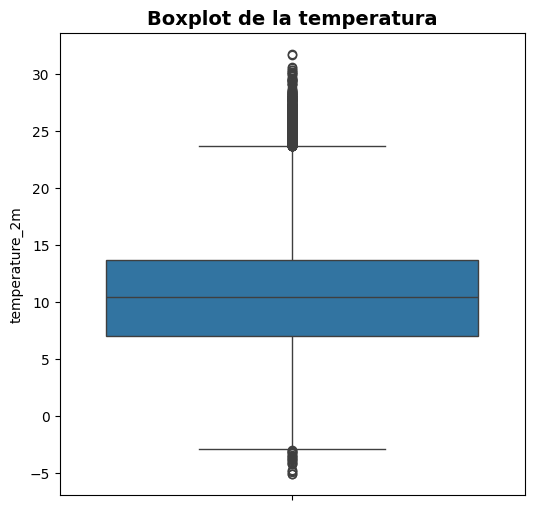

In [12]:
plt.figure(figsize=(6,6))

sb.boxplot(y=data['temperature_2m'])

plt.title(
    'Boxplot de la temperatura',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### Interpretación:

Se identificaron valores atípicos mediante el método del rango intercuartílico. Se observan valores extremos principalmente en temperatura, precipitación, lluvia y velocidad del viento.

En este contexto, los valores atípicos no necesariamente representan errores, ya que pueden corresponder a eventos climáticos reales. Por esta razón, no se eliminaron directamente. En su lugar, se aplicará winsorización dentro del pipeline para reducir su impacto sin perder registros del conjunto de datos.

## Creación de variables temporales

In [13]:
data["fecha"] = pd.to_datetime(data["date"])

data["hora"] = data["fecha"].dt.hour
data["mes"] = data["fecha"].dt.month

data[["fecha", "hora", "mes"]].head()

,fecha,hora,mes
0,2025-01-01 03:00:00+00:00,3,1
1,2025-01-01 04:00:00+00:00,4,1
2,2025-01-01 05:00:00+00:00,5,1
3,2025-01-01 06:00:00+00:00,6,1
4,2025-01-01 07:00:00+00:00,7,1


### Interpretación:

A partir de la columna `date` se generó la variable `fecha` en formato datetime. Luego se obtuvieron las variables `hora` y `mes`, ya que la temperatura puede variar según el momento del día y la época del año.

Estas variables permiten incorporar información temporal relevante para el modelamiento predictivo.

## Transformación cíclica de hora y mes

In [14]:
data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

data[[
    "hora",
    "hora_sin",
    "hora_cos",
    "mes",
    "mes_sin",
    "mes_cos"
]].head()

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,3,0.707107,7.071068e-01,1,0.5,0.866025
1,4,0.866025,5.000000e-01,1,0.5,0.866025
2,5,0.965926,2.588190e-01,1,0.5,0.866025
3,6,1.000000,6.123234e-17,1,0.5,0.866025
4,7,0.965926,-2.588190e-01,1,0.5,0.866025


### Interpretación:

Se aplicó una transformación cíclica a las variables `hora` y `mes` utilizando funciones seno y coseno.

Esta transformación permite representar correctamente variables temporales con comportamiento circular. Por ejemplo, las 23:00 y las 00:00 son horas cercanas, aunque numéricamente puedan parecer lejanas. Lo mismo ocurre entre diciembre y enero.

De esta manera, el modelo puede interpretar de mejor forma los ciclos diarios y estacionales presentes en los datos.

## Creación de rezagos y ventanas móviles

Antes de crear rezagos y ventanas móviles, los datos fueron ordenados por localidad y fecha. Esta decisión permite respetar el orden cronológico de las observaciones dentro de cada ciudad.

Las ventanas fueron generadas de forma sectorizada por localidad, ya que cada ciudad presenta condiciones climáticas propias. De esta forma, se evita mezclar información histórica de una localidad con otra.

In [15]:
data = data.sort_values(["Localidad", "fecha"]).copy()

## Crear rezagos (lags)

In [16]:
data["temp_lag_1h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(1)
)

data["temp_lag_2h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(2)
)

data["temp_lag_3h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(3)
)

data["temp_lag_12h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(12)
)

data["temp_lag_24h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(24)
)

data["temp_tendencia_1h"] = (
    data["temp_lag_1h"] - data["temp_lag_2h"]
)

## Creación de rezagos de variables climáticas auxiliares

In [17]:
data["humedad_lag_1h"] = (
    data.groupby("Localidad")["relative_humidity_2m"].shift(1)
)

data["humedad_lag_2h"] = (
    data.groupby("Localidad")["relative_humidity_2m"].shift(2)
)

data["apparent_lag_1h"] = (
    data.groupby("Localidad")["apparent_temperature"].shift(1)
)

data["apparent_lag_2h"] = (
    data.groupby("Localidad")["apparent_temperature"].shift(2)
)

data["nubes_lag_1h"] = (
    data.groupby("Localidad")["cloud_cover"].shift(1)
)

data["sunshine_lag_1h"] = (
    data.groupby("Localidad")["sunshine_duration"].shift(1)
)

data["apparent_lag_3h"] = (
    data.groupby("Localidad")["apparent_temperature"].shift(3)
)

data["apparent_lag_24h"] = (
    data.groupby("Localidad")["apparent_temperature"].shift(24)
)

data["humedad_lag_24h"] = (
    data.groupby("Localidad")["relative_humidity_2m"].shift(24)
)

data["temp_lag_25h"] = (
    data.groupby("Localidad")["temperature_2m"].shift(25)
)

data["temp_tendencia_24h"] = (
    data["temp_lag_1h"] - data["temp_lag_25h"]
)

## Creación de ventanas móviles

In [18]:
data["temp_rolling_3h"] = (
    data.groupby("Localidad")["temperature_2m"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(0, drop=True)
)

data["temp_rolling_6h"] = (
    data.groupby("Localidad")["temperature_2m"]
    .shift(1)
    .rolling(6)
    .mean()
    .reset_index(0, drop=True)
)

data["temp_rolling_24h"] = (
    data.groupby("Localidad")["temperature_2m"]
    .shift(1)
    .rolling(24)
    .mean()
    .reset_index(0, drop=True)
)

data["humidity_rolling_3h"] = (
    data.groupby("Localidad")["relative_humidity_2m"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(0, drop=True)
)

data["humidity_rolling_12h"] = (
    data.groupby("Localidad")["relative_humidity_2m"]
    .shift(1)
    .rolling(12)
    .mean()
    .reset_index(0, drop=True)
)

data["wind_rolling_12h"] = (
    data.groupby("Localidad")["wind_speed_10m"]
    .shift(1)
    .rolling(12)
    .mean()
    .reset_index(0, drop=True)
)

data["lluvia_rolling_24h"] = (
    data.groupby("Localidad")["precipitation"]
    .shift(1)
    .rolling(24)
    .sum()
    .reset_index(0, drop=True)
)

### Interpretación:

Se generaron variables de rezago y ventanas móviles para incorporar información histórica al modelo.

Los rezagos permiten utilizar valores de horas anteriores, mientras que las ventanas móviles resumen el comportamiento reciente de variables como temperatura, humedad, viento y precipitación.

Para evitar fuga de información, las ventanas móviles fueron construidas utilizando `shift(1)`, por lo que cada registro solo utiliza información disponible antes del momento de predicción.

## Tratamiento de nulos generados por rezagos y ventanas

In [19]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


## Eliminar nulos generados

In [20]:
data = data.dropna().copy()

In [21]:
data[[
    "temperature_2m",
    "temp_lag_1h",
    "temp_lag_2h",
    "temp_lag_3h",
    "temp_rolling_3h",
    "temp_rolling_6h",
    "temp_rolling_24h",
    "humidity_rolling_3h",
    "humidity_rolling_12h"
]].head()

,temperature_2m,temp_lag_1h,temp_lag_2h,temp_lag_3h,temp_rolling_3h,temp_rolling_6h,temp_rolling_24h,humidity_rolling_3h,humidity_rolling_12h
25,16.10,16.65,16.80,15.95,16.466667,17.608333,17.314583,75.905510,56.597718
26,15.45,16.10,16.65,16.80,16.516667,16.875000,17.364583,71.882021,58.755496
27,15.00,15.45,16.10,16.65,16.066667,16.316667,17.408333,69.188968,60.966513
28,14.30,15.00,15.45,16.10,15.516667,15.991667,17.454167,69.795235,63.126773
29,13.55,14.30,15.00,15.45,14.916667,15.716667,17.491667,73.132419,65.645992


### Interpretación:

La creación de rezagos y ventanas móviles generó valores nulos al inicio de cada serie temporal, debido a que no existen observaciones anteriores suficientes para calcular esas variables.

Estos registros fueron eliminados después de crear las variables temporales, ya que representan una proporción reducida del total de datos y no afectan de forma significativa el volumen disponible para el modelamiento.

## Transformación de variables binarias a categóricas

In [22]:
data["is_rainy_hour"] = data["is_rainy_hour"].map({
    0: "No llueve",
    1: "Llueve"
})

data["is_day"] = data["is_day"].map({
    0: "Noche",
    1: "Día"
})

### Interpretación:

Las variables `is_day` e `is_rainy_hour` fueron transformadas a categorías descriptivas. Esto permite tratarlas como variables cualitativas dentro del pipeline y aplicarles codificación mediante OneHotEncoder.

## Evaluación de variables predictoras

In [23]:
correlaciones = data.corr(numeric_only=True)

correlacion_objetivo = correlaciones["temperature_2m"].sort_values(
    ascending=False
)

correlacion_objetivo

,temperature_2m
temperature_2m,1.000000
temp_lag_1h,0.983543
apparent_temperature,0.970122
apparent_lag_1h,0.959795
temp_lag_2h,0.942960
apparent_lag_2h,0.928626
temp_lag_24h,0.906501
temp_lag_25h,0.891955
apparent_lag_24h,0.886018
temp_lag_3h,0.885510


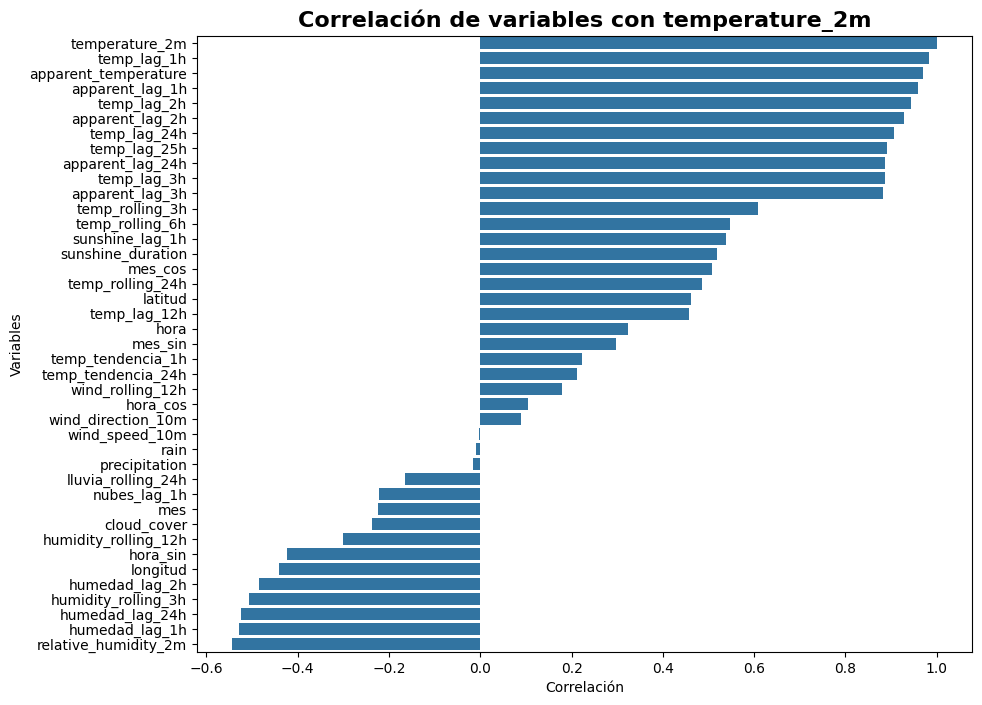

In [24]:
plt.figure(figsize=(10, 8))

sb.barplot(
    x=correlacion_objetivo.values,
    y=correlacion_objetivo.index
)

plt.title(
    "Correlación de variables con temperature_2m",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.show()

### Interpretación:

Se calculó la correlación de las variables numéricas con la variable objetivo `temperature_2m`, con el fin de apoyar la selección de variables predictoras.

Se observa que algunas variables históricas, como los rezagos de temperatura y de sensación térmica, presentan alta relación con la temperatura actual. Estas variables se consideran relevantes porque representan información pasada disponible antes del momento de predicción.

La selección final de variables no se basó únicamente en la correlación, sino también en el criterio de funcionalidad del modelo y en la necesidad de evitar el uso de información futura.

## Definición de variable objetivo y variables predictoras

In [25]:
target = "temperature_2m"

features_num = [
    "relative_humidity_2m",
    "cloud_cover",
    "precipitation",
    "wind_speed_10m",
    "wind_direction_10m",
    "sunshine_duration",

    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",

    "temp_lag_1h",
    "temp_lag_12h",
    "temp_lag_24h",
    "temp_tendencia_1h",
    "temp_tendencia_24h",

    "temp_rolling_3h",
    "temp_rolling_6h",
    "temp_rolling_24h",

    "humedad_lag_1h",
    "humedad_lag_24h",
    "humidity_rolling_3h",
    "humidity_rolling_12h",

    "apparent_lag_1h",
    "apparent_lag_24h",

    "nubes_lag_1h",
    "sunshine_lag_1h",
    "wind_rolling_12h",
    "lluvia_rolling_24h",

    "latitud",
    "longitud"
]

features_cat = [
    "Localidad",
    "is_day",
    "is_rainy_hour"
]

features = features_num + features_cat

X = data[features]
y = data[target]

X.head()

,relative_humidity_2m,cloud_cover,precipitation,wind_speed_10m,wind_direction_10m,sunshine_duration,hora_sin,hora_cos,mes_sin,mes_cos,...,apparent_lag_24h,nubes_lag_1h,sunshine_lag_1h,wind_rolling_12h,lluvia_rolling_24h,latitud,longitud,Localidad,is_day,is_rainy_hour
25,67.133560,0.0,0.0,11.367109,190.95403,0.0,0.866025,5.000000e-01,0.5,0.866025,...,12.787600,0.0,0.0,16.479034,0.0,-36.82707,-73.050206,"Concepción, Chile",Noche,No llueve
26,70.217310,0.0,0.0,9.957109,192.52880,0.0,0.965926,2.588190e-01,0.5,0.866025,...,12.131762,0.0,0.0,16.448413,0.0,-36.82707,-73.050206,"Concepción, Chile",Noche,No llueve
27,72.034836,0.0,0.0,10.132897,192.30800,0.0,1.000000,6.123234e-17,0.5,0.866025,...,11.714258,0.0,0.0,16.016744,0.0,-36.82707,-73.050206,"Concepción, Chile",Noche,No llueve
28,77.145110,0.0,0.0,9.144637,190.20392,0.0,0.965926,-2.588190e-01,0.5,0.866025,...,11.426943,0.0,0.0,15.424124,0.0,-36.82707,-73.050206,"Concepción, Chile",Noche,No llueve
29,82.352180,0.0,0.0,5.626259,172.64772,0.0,0.866025,-5.000000e-01,0.5,0.866025,...,11.337353,0.0,0.0,14.663179,0.0,-36.82707,-73.050206,"Concepción, Chile",Noche,No llueve


In [26]:
y.head()

,temperature_2m
25,16.10
26,15.45
27,15.00
28,14.30
29,13.55


### Interpretación:

Se definió como variable objetivo `temperature_2m`. Las variables predictoras seleccionadas incluyen información climática, temporal, geográfica y variables históricas generadas mediante rezagos y ventanas móviles.

La variable `apparent_temperature` no fue utilizada en su valor actual, ya que presenta una alta relación con la temperatura del mismo instante. En su lugar, se incorporaron rezagos de esta variable, los cuales representan información histórica disponible antes del momento de predicción.

## División de datos en entrenamiento y prueba

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=29
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26339, 33)
X_test: (6585, 33)
y_train: (26339,)
y_test: (6585,)


### Interpretación:

El conjunto de datos fue dividido en entrenamiento y prueba mediante `train_test_split`, utilizando un 80% de los registros para entrenamiento y un 20% para prueba.

Si bien esta división no corresponde a una separación temporal estricta, las variables temporales utilizadas en el modelo fueron construidas mediante rezagos y ventanas móviles con `shift(1)`, usando únicamente información pasada. Esto permite mantener la funcionalidad del modelo y evitar el uso de información futura dentro de las variables predictoras.

## Clases personalizadas para preparación de datos

## Tratamiento de valores atípicos

In [28]:
class Winsorizer(BaseEstimator, TransformerMixin):

    # Se utiliza un recorte suave para disminuir el efecto de valores extremos sin eliminar registros.
    def __init__(self, limits=(0.001, 0.001)):
        self.limits = limits

    def fit(self, X, y=None):

        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])

        return self

    def transform(self, X):

        X = pd.DataFrame(X, columns=self.columns_)

        for col in self.columns_:

            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])

            X[col] = np.clip(X[col], lower, upper)

        return X.values

    def get_feature_names_out(self, input_features=None):

        if input_features is None:
            return np.array(self.columns_)

        return np.array(input_features)

## Filtro de colinealidad

In [29]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.9):

        self.threshold = threshold
        self.columns_to_drop_ = None

    def fit(self, X, y=None):

        X_df = pd.DataFrame(X)

        corr_matrix = X_df.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.columns_to_drop_ = [
            col for col in upper.columns
            if any(upper[col] > self.threshold)
        ]

        return self

    def transform(self, X):

        X_df = pd.DataFrame(X)

        X_filtered = X_df.drop(
            columns=self.columns_to_drop_,
            errors="ignore"
        )

        return X_filtered.values

### Interpretación:

Se implementaron clases personalizadas para apoyar la preparación de datos dentro del pipeline.

La clase `Winsorizer` permite reducir el impacto de valores extremos sin eliminar registros. Esto es útil en variables climáticas, donde los valores atípicos pueden representar eventos reales.

La clase `CorrelationFilter` permite eliminar variables altamente correlacionadas después del preprocesamiento, lo que ayuda especialmente al modelo de regresión lineal, ya que reduce problemas de colinealidad entre variables predictoras.

## Preprocesamiento de variables cuantitativas y cualitativas

In [30]:
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.001, 0.001))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsorizer', Winsorizer()),
                                                 ('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['relative_humidity_2m', 'cloud_cover',
                                  'precipitation', 'wind_speed_10m',
                                  'wind_direction_10m', 'sunshine_duration',
                                  'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
                                  'temp_lag_1h', 'temp_lag_12h', 'temp_lag_24h',
                                  'temp_tende...
                                  'humedad_lag_24h', 'humidity_rolling_3h',
                                  'humidity_rolling_12h', 'apparent_lag_1h',
                                  'apparent_lag_24h', 'nubes_lag_1h',
                                  'sunshine_lag_1h', 'wind_rolling_12h',
                                  'lluvia_rolling_24h', 'latitud',
                                  'longitud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Localidad', 'is_day', 'is_rainy_hour'])])

### Interpretación:

Se definió un preprocesamiento diferenciado para variables cuantitativas y cualitativas.

En las variables cuantitativas se aplicó winsorización, imputación mediante la media y escalado estándar. En las variables cualitativas se aplicó imputación con la categoría más frecuente y codificación OneHotEncoder.

Estas transformaciones se incorporaron dentro de un pipeline para asegurar que el mismo tratamiento se aplique de forma consistente durante el entrenamiento y la evaluación de los modelos.

## Definición de pipelines de modelamiento

In [31]:
pipeline_lr_temperature = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LinearRegression())
])

pipeline_dt_temperature = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo", DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=15,
        min_samples_leaf=7,
        random_state=29
    ))
])

In [32]:
pipeline_lr_temperature

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'cloud_cover',
                                                   'precipitation',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_lag_1h',
                                                   'temp...
                                                   'apparent_lag_24h',
                                                   'nubes_lag_1h',
                                                   'sunshine_lag_1h',
                                                   'wind_rolling_12h',
                                                   'lluvia_rolling_24h',
                                                   'latitud', 'longitud']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [33]:
pipeline_dt_temperature

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'cloud_cover',
                                                   'precipitation',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_lag_1h',
                                                   'temp...
                                                   'wind_rolling_12h',
                                                   'lluvia_rolling_24h',
                                                   'latitud', 'longitud']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour'])])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=7,
                                       min_samples_split=15,
                                       random_state=29))])

### Interpretación:

Se construyeron dos pipelines de modelamiento utilizando los algoritmos solicitados: `LinearRegression` y `DecisionTreeRegressor`.

El modelo de regresión lineal se utiliza como una alternativa simple e interpretable. Además, incorpora un filtro de colinealidad para reducir variables altamente correlacionadas después del preprocesamiento.

El árbol de decisión se utiliza como una alternativa capaz de capturar relaciones no lineales entre las variables predictoras y la temperatura.

## Entrenamiento de los modelos

In [34]:
pipeline_lr_temperature.fit(X_train, y_train)
pipeline_dt_temperature.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'cloud_cover',
                                                   'precipitation',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m',
                                                   'sunshine_duration',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_lag_1h',
                                                   'temp...
                                                   'wind_rolling_12h',
                                                   'lluvia_rolling_24h',
                                                   'latitud', 'longitud']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour'])])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=7,
                                       min_samples_split=15,
                                       random_state=29))])

### Interpretación:

Los modelos fueron entrenados utilizando el conjunto de entrenamiento. De esta forma, las transformaciones del pipeline y el ajuste de los modelos se realizan sin utilizar información del conjunto de prueba.

## Evaluación de los modelos

In [35]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados = {
        "Modelo": nombre,
        "R2 Train": r2_score(y_train, pred_train),
        "R2 Test": r2_score(y_test, pred_test),
        "MAE Train": mean_absolute_error(y_train, pred_train),
        "MAE Test": mean_absolute_error(y_test, pred_test)
    }

    return resultados

In [36]:
resultados = [
    evaluar_modelo(
        "LinearRegression",
        pipeline_lr_temperature,
        X_train,
        y_train,
        X_test,
        y_test
    ),
    evaluar_modelo(
        "DecisionTreeRegressor",
        pipeline_dt_temperature,
        X_train,
        y_train,
        X_test,
        y_test
    )
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados["Diferencia MAE"] = abs(
    tabla_resultados["MAE Test"] - tabla_resultados["MAE Train"]
)

tabla_resultados["Condición"] = np.where(
    tabla_resultados["Diferencia MAE"] > 0.15,
    "Posible Overfitting",
    "Sin evidencia fuerte de overfitting"
)

tabla_resultados.round(4)

,Modelo,R2 Train,R2 Test,MAE Train,MAE Test,Diferencia MAE,Condición
0,LinearRegression,0.9906,0.9905,0.3715,0.3714,0.0001,Sin evidencia fuerte de overfitting
1,DecisionTreeRegressor,0.9919,0.9860,0.3489,0.4420,0.0932,Sin evidencia fuerte de overfitting


### Interpretación:

Los modelos fueron evaluados mediante las métricas R2 y MAE, tanto en entrenamiento como en prueba.

El modelo LinearRegression obtiene el mejor desempeño general, alcanzando un R2 de prueba superior al 95% y un MAE de prueba igual o inferior a 0,38. Además, la diferencia entre el MAE de entrenamiento y prueba es mínima, por lo que no se observa evidencia fuerte de sobreajuste.

El modelo DecisionTreeRegressor también presenta un buen nivel de explicación según R2, pero obtiene un MAE mayor en comparación con LinearRegression. Por esta razón, el modelo seleccionado como mejor alternativa es LinearRegression.

## Visualización del rendimiento de los modelos



In [37]:
y_pred_lr = pipeline_lr_temperature.predict(X_test)
y_pred_dt = pipeline_dt_temperature.predict(X_test)

### Gráfico LinearRegression

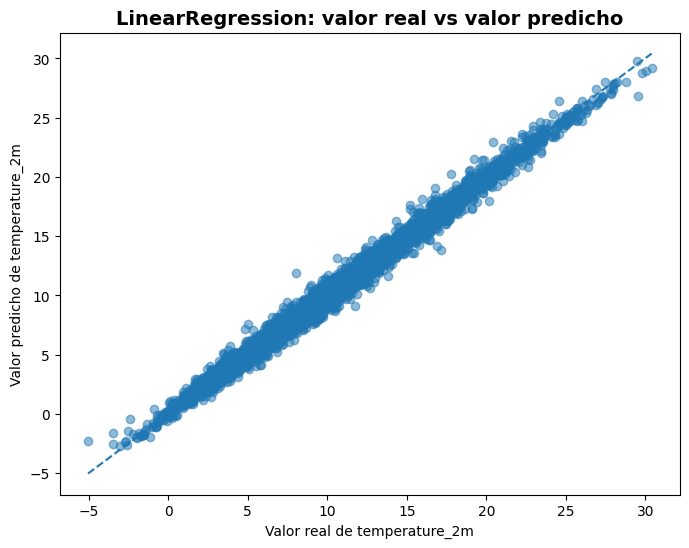

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "LinearRegression: valor real vs valor predicho",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Valor real de temperature_2m")
plt.ylabel("Valor predicho de temperature_2m")

plt.show()

### Interpretación:

El gráfico muestra la comparación entre los valores reales de temperatura y las predicciones generadas por DecisionTreeRegressor.

El modelo logra aproximarse a los valores reales, aunque se observa una dispersión ligeramente mayor en comparación con L

### Gráfico DecisionTreeRegressor



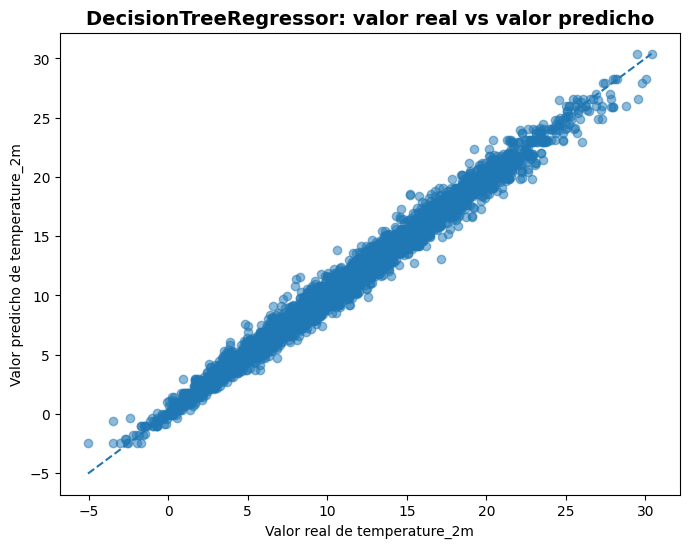

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_dt, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "DecisionTreeRegressor: valor real vs valor predicho",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Valor real de temperature_2m")
plt.ylabel("Valor predicho de temperature_2m")

plt.show()

### Interpretación:

El gráfico compara los valores reales de temperatura con los valores predichos por el modelo LinearRegression.

Se observa que la mayoría de los puntos se ubican cerca de la línea diagonal, lo que indica que las predicciones son cercanas a los valores reales. Este resultado es coherente con las métricas obtenidas, donde LinearRegression presenta un MAE bajo y una diferencia mínima entre entrenamiento y prueba.

## Uso recomendado de cada modelo

### Interpretación:

De acuerdo con los resultados obtenidos, el modelo LinearRegression sería utilizado como modelo principal para este problema, ya que presenta el menor MAE en el conjunto de prueba, un R2 superior al 95% y una diferencia mínima entre entrenamiento y prueba. Esto indica que mantiene un buen equilibrio entre capacidad predictiva y generalización.

El modelo DecisionTreeRegressor podría utilizarse como modelo complementario cuando se requiera interpretar reglas de decisión o analizar relaciones no lineales entre las variables climáticas y la temperatura. Sin embargo, en este caso no se selecciona como modelo principal, ya que su MAE de prueba es mayor que el obtenido por LinearRegression.

## Predicción de una nueva observación

### Seleccionar una observación del conjunto de prueba

In [40]:
nueva_observacion = X_test.iloc[[0]]


## Predicción con LinearRegression

In [41]:
pred_lr = pipeline_lr_temperature.predict(nueva_observacion)

print("Predicción LinearRegression:", pred_lr[0])

Predicción LinearRegression: 3.6930828585900306


### Predicción con DecisionTreeRegressor

In [42]:
pred_dt = pipeline_dt_temperature.predict(nueva_observacion)

print("Predicción DecisionTreeRegressor:", pred_dt[0])

Predicción DecisionTreeRegressor: 3.9230000153846145


### Valor real

In [43]:
valor_real = y_test.iloc[0]

print("Valor real:", valor_real)

Valor real: 3.55


### Interpretación:

Se seleccionó una observación del conjunto de prueba para comparar el valor real de la temperatura con las predicciones generadas por ambos modelos.

Ambos modelos entregan valores cercanos al valor real. Sin embargo, LinearRegression presenta mejor desempeño global en la tabla de evaluación, por lo que se considera el modelo más adecuado para este caso.

## Exportación del conjunto de datos preparado

### Dataset preparado para modelamiento

In [44]:
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,...,humedad_lag_24h,temp_lag_25h,temp_tendencia_24h,temp_rolling_3h,temp_rolling_6h,temp_rolling_24h,humidity_rolling_3h,humidity_rolling_12h,wind_rolling_12h,lluvia_rolling_24h
25,2025-01-02 04:00:00+00:00,16.10,67.133560,14.457993,0.0,0.0,11.367109,190.95403,0.0,Noche,...,64.437440,15.1,1.55,16.466667,17.608333,17.314583,75.905510,56.597718,16.479034,0.0
26,2025-01-02 05:00:00+00:00,15.45,70.217310,14.028061,0.0,0.0,9.957109,192.52880,0.0,Noche,...,63.023464,14.9,1.20,16.516667,16.875000,17.364583,71.882021,58.755496,16.448413,0.0
27,2025-01-02 06:00:00+00:00,15.00,72.034836,13.538231,0.0,0.0,10.132897,192.30800,0.0,Noche,...,65.991730,14.4,1.05,16.066667,16.316667,17.408333,69.188968,60.966513,16.016744,0.0
28,2025-01-02 07:00:00+00:00,14.30,77.145110,13.083412,0.0,0.0,9.144637,190.20392,0.0,Noche,...,70.770430,13.9,1.10,15.516667,15.991667,17.454167,69.795235,63.126773,15.424124,0.0
29,2025-01-02 08:00:00+00:00,13.55,82.352180,12.920006,0.0,0.0,5.626259,172.64772,0.0,Noche,...,78.494840,13.4,0.90,14.916667,15.716667,17.491667,73.132419,65.645992,14.663179,0.0


In [45]:
data.shape

(32924, 46)

In [46]:
data.to_csv("data_modelo_G1.csv", index=False)

### Interpretación:

El conjunto de datos preparado incorpora las variables originales, las transformaciones temporales, los rezagos y las ventanas móviles utilizadas en el modelamiento.

Finalmente, el dataset fue exportado en formato CSV con el nombre solicitado, permitiendo conservar el resultado de la fase de preparación de datos y facilitar su reutilización.